# Build an LLM From Scratch Lab

A transformer-based language model is a long chain of simple ideas that build on one another.

In this notebook we will start with raw text, turn it into tokens, map those tokens into vectors, let attention mix information across positions, stack those computations into transformer blocks, train a tiny language model, and then connect our educational build to GPT-2 Small.

This is a notebook about understanding, not benchmark chasing. We will keep the examples tiny enough to inspect by hand before we scale up to short educational training runs.


## How To Use This Notebook

- Run the notebook from top to bottom the first time so every output stays aligned with the story.
- Pause at the interpretation blocks after each important output. They explain what changed and why the step matters.
- Treat the code as editable lab material. Every function and class is intentionally small enough to inspect.
- Expect the training runs to be educational, not state of the art. They are designed for CPU or a basic Colab session.


In [1]:
import importlib.util
import contextlib
import io
import math
import random
import re
import subprocess
import sys

required = {
    "matplotlib": "matplotlib",
    "requests": "requests",
    "torch": "torch",
    "transformers": "transformers",
}
missing = [pkg for pkg, module in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer

random.seed(7)
torch.manual_seed(7)
device = "cuda" if torch.cuda.is_available() else "cpu"
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Device: {device}")


Python: 3.13.9
PyTorch: 2.10.0+cpu
Transformers: 5.3.0
Device: cpu


## Phase 0. Roadmap

We will follow the same learning arc that a language model follows computationally:

1. **Text to tokens**: make discrete symbols that a model can index.
2. **Tokens to embeddings**: replace ids with dense vectors.
3. **Positional information**: inject token order.
4. **Single-head attention**: compute which earlier tokens matter for the current token.
5. **Multi-head attention**: let several attention patterns coexist.
6. **MLP and residual stream**: refine and preserve information.
7. **Transformer language model**: compose the full block stack and produce logits.
8. **Autoregressive generation**: predict one next token at a time.
9. **Stage A training**: learn on tiny synthetic text we can fully understand.
10. **Stage B training**: move to a tiny Project Gutenberg corpus.
11. **GPT-2 Small comparison**: connect the educational build to a real pretrained model.


In [2]:
def rounded(tensor, decimals=3):
    factor = 10 ** decimals
    return torch.round(tensor.detach().cpu() * factor) / factor


def plot_matrix(matrix, row_labels, col_labels, title, cmap="Blues"):
    data = matrix.detach().cpu()
    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    image = ax.imshow(data, cmap=cmap)
    ax.set_xticks(range(len(col_labels)), labels=col_labels, rotation=45, ha="right")
    ax.set_yticks(range(len(row_labels)), labels=row_labels)
    ax.set_title(title)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_loss_curves(history, title):
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(history["steps"], history["train"], marker="o", label="train loss")
    ax.plot(history["steps"], history["val"], marker="s", label="val loss")
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    plt.tight_layout()
    plt.show()


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


print("Display helpers are ready.")


Display helpers are ready.


## Phase 1. Text To Tokens

The model cannot work directly with raw strings. It needs a discrete vocabulary.

We start with a tiny regex-based word tokenizer because it makes the conversion visible:

\[
\text{token ids} = \text{vocab lookup}(\text{Tokenizer}(\text{text}))
\]

Later we will intentionally switch to a character-level tokenizer for the scratch model. That simplification keeps training fast and makes every prediction easy to inspect.


In [3]:
sample_text = "The capital of France is Paris."
word_pattern = re.compile(r"[A-Za-z']+|[.,!?;:]")


def word_tokenize(text):
    return word_pattern.findall(text)


def word_detokenize(tokens):
    pieces = []
    for token in tokens:
        if token in ".,!?;:":
            pieces.append(token)
        elif not pieces:
            pieces.append(token)
        else:
            pieces.append(" " + token)
    return "".join(pieces)


word_tokens = word_tokenize(sample_text)
word_stoi = {token: idx for idx, token in enumerate(sorted(set(word_tokens)))}
word_itos = {idx: token for token, idx in word_stoi.items()}


def word_encode(text):
    return [word_stoi[token] for token in word_tokenize(text)]


def word_decode(ids):
    return word_detokenize([word_itos[idx] for idx in ids])


encoded_words = word_encode(sample_text)
print("Sample text:", sample_text)
print("Word tokens:", word_tokens)
print("Word vocabulary:", word_stoi)
print("Encoded ids:", encoded_words)
print("Decoded text:", word_decode(encoded_words))


Sample text: The capital of France is Paris.
Word tokens: ['The', 'capital', 'of', 'France', 'is', 'Paris', '.']
Word vocabulary: {'.': 0, 'France': 1, 'Paris': 2, 'The': 3, 'capital': 4, 'is': 5, 'of': 6}
Encoded ids: [3, 4, 6, 1, 5, 2, 0]
Decoded text: The capital of France is Paris.


### What I am looking at

A single sentence has been broken into a short list of word and punctuation tokens, then mapped into integer ids.

### What changed here

We moved from continuous text to a finite vocabulary lookup. The tokenizer decided where token boundaries live, and the vocabulary assigned each token a stable integer.

### Why it matters

Everything that follows depends on this discrete interface. Embeddings, attention, logits, and loss all operate on token ids rather than raw text.


### Why Switch To Characters For The Scratch Model?

A word-level tokenizer is good for intuition, but it becomes awkward for a tiny educational training run because every new word can become an out-of-vocabulary problem.

A character-level tokenizer is slower for real models but perfect for a small lab:

- every visible symbol becomes learnable
- vocabulary size stays tiny
- decoding is easy to inspect
- we can train quickly on CPU or in Colab


In [4]:
toy_sentences = [
    "The capital of France is Paris.",
    "The capital of Italy is Rome.",
    "The capital of Japan is Tokyo.",
    "The capital of Brazil is Brasilia.",
    "The capital of Egypt is Cairo.",
    "The capital of India is New Delhi.",
    "2 plus 2 equals 4.",
    "3 plus 3 equals 6.",
    "4 plus 4 equals 8.",
    "The red bird sings at dawn.",
    "The blue bird sings at dusk.",
    "A small fox sees the moon.",
    "A small fox sees the sun.",
]
toy_preview_text = "\n".join(toy_sentences)


def build_char_tokenizer(text):
    chars = sorted(set(text))
    stoi = {ch: idx for idx, ch in enumerate(chars)}
    itos = {idx: ch for ch, idx in stoi.items()}

    def encode(text_fragment):
        return [stoi[ch] for ch in text_fragment]

    def decode(ids):
        return "".join(itos[idx] for idx in ids)

    return chars, stoi, itos, encode, decode


preview_chars, preview_stoi, preview_itos, preview_encode, preview_decode = build_char_tokenizer(toy_preview_text)
preview_text = "The capital of Japan is Tokyo."
preview_ids = preview_encode(preview_text)

print("Character vocabulary size:", len(preview_chars))
print("First 20 characters in the vocabulary:", preview_chars[:20])
print("Preview text:", preview_text)
print("Encoded ids (first 20):", preview_ids[:20])
print("Decoded text:", preview_decode(preview_ids))


Character vocabulary size: 44
First 20 characters in the vocabulary: ['\n', ' ', '.', '2', '3', '4', '6', '8', 'A', 'B', 'C', 'D', 'E', 'F', 'I', 'J', 'N', 'P', 'R', 'T']
Preview text: The capital of Japan is Tokyo.
Encoded ids (first 20): [19, 27, 24, 1, 22, 20, 34, 28, 38, 20, 30, 1, 33, 25, 1, 15, 20, 34, 20, 32]
Decoded text: The capital of Japan is Tokyo.


### What I am looking at

The same text interface has been rebuilt at character level, so every letter, space, punctuation mark, and newline gets its own id.

### What changed here

We shrank the vocabulary dramatically and made tokenization lossless for this tiny corpus. The encoder and decoder now operate character by character.

### Why it matters

This simplification makes the later training runs practical and easy to debug. Every next-token prediction becomes a next-character prediction we can read directly.


## Phase 2. Tokens To Embeddings

Token ids are discrete labels, but transformer blocks operate on vectors. An embedding table performs a learned lookup:

\[
\mathbf{x}_i = E[\text{token}_i]
\]

Each row of the embedding matrix is a trainable vector. Looking up token ids pulls out the rows associated with the current sequence.


In [5]:
embedding_dim = 6
token_embedding = nn.Embedding(len(preview_chars), embedding_dim)
lookup_text = "Rome."
lookup_ids = torch.tensor(preview_encode(lookup_text), dtype=torch.long)
lookup_vectors = token_embedding(lookup_ids)

print("Lookup text:", lookup_text)
print("Token ids:", lookup_ids.tolist())
print("Embedding table shape:", tuple(token_embedding.weight.shape))
print("Lookup result shape:", tuple(lookup_vectors.shape))
print("Embedding vectors:")
print(rounded(lookup_vectors))


Lookup text: Rome.
Token ids: [18, 33, 31, 24, 2]
Embedding table shape: (44, 6)
Lookup result shape: (5, 6)
Embedding vectors:
tensor([[ 0.5070, -0.1580,  0.4600, -1.1530, -1.1250, -0.3140],
        [-1.4270, -0.2680, -2.6340, -0.0230,  0.7390,  0.6630],
        [ 1.5330, -0.7750, -2.1510, -1.2800, -0.9890, -0.0040],
        [ 0.2610, -0.1490,  1.1520, -1.1310,  2.0870, -0.5310],
        [ 0.7090,  1.0130,  0.2300,  1.0900, -1.5830, -0.3250]])


### What I am looking at

Each character id in `"Rome."` has been replaced by a length-6 vector taken from the embedding table.

### What changed here

The model moved from symbolic ids to dense numeric features. Two identical token ids would retrieve the same row from the table.

### Why it matters

Attention and MLP blocks need continuous representations. Embeddings are the first trainable bridge from symbols to geometry.


## Phase 3. Positional Information

Embeddings alone do not tell the model where a token appears. A bag of token vectors loses word order.

A simple fix is to learn a positional embedding for each slot and add it to the token embedding:

\[
\mathbf{h}_i^{(0)} = E[\text{token}_i] + P[i]
\]


In [6]:
repeat_ids = torch.tensor([preview_stoi["a"]] * 4, dtype=torch.long)
position_embedding = nn.Embedding(4, embedding_dim)
repeat_token_vectors = token_embedding(repeat_ids)
position_indices = torch.arange(4, dtype=torch.long)
position_vectors = position_embedding(position_indices)
combined_vectors = repeat_token_vectors + position_vectors

print("Repeated token ids:", repeat_ids.tolist())
print("Token embeddings (same token repeated):")
print(rounded(repeat_token_vectors))
print("\nPosition embeddings:")
print(rounded(position_vectors))
print("\nCombined token + position states:")
print(rounded(combined_vectors))


Repeated token ids: [20, 20, 20, 20]
Token embeddings (same token repeated):
tensor([[-0.8160,  1.1560, -1.2110,  0.5070, -0.4310,  0.6130],
        [-0.8160,  1.1560, -1.2110,  0.5070, -0.4310,  0.6130],
        [-0.8160,  1.1560, -1.2110,  0.5070, -0.4310,  0.6130],
        [-0.8160,  1.1560, -1.2110,  0.5070, -0.4310,  0.6130]])

Position embeddings:
tensor([[ 0.6390, -0.3920, -0.5870, -0.7060,  0.3560, -1.1180],
        [-0.3470,  0.1560,  0.6460, -0.6670,  0.3230,  0.4360],
        [ 0.9050,  0.3750,  1.1050,  0.0910,  0.6760, -0.4790],
        [-0.8270, -0.0600,  0.6130, -0.2350, -1.5140,  0.1700]])

Combined token + position states:
tensor([[-0.1770,  0.7640, -1.7970, -0.1980, -0.0750, -0.5050],
        [-1.1630,  1.3120, -0.5640, -0.1590, -0.1080,  1.0490],
        [ 0.0890,  1.5310, -0.1060,  0.5980,  0.2450,  0.1350],
        [-1.6430,  1.0960, -0.5970,  0.2720, -1.9450,  0.7830]])


### What I am looking at

The repeated token `"a"` starts with the same embedding at every position, then becomes position-specific once we add the learned positional vectors.

### What changed here

Order information entered the representation. The model can now distinguish `"a"` in position 0 from `"a"` in position 3.

### Why it matters

Language depends on sequence order. Without positional information, attention would know what tokens exist but not where they appear.


## Phase 4. Single-Head Self-Attention

Self-attention lets each token build a weighted summary of earlier tokens.

For one attention head we create three linear projections:

\[
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
\]

Then we compare queries to keys, scale the scores, mask future positions, and take a weighted sum of values:

\[
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + \text{mask}\right)V
\]


Query vectors:
tensor([[ 0.5110, -0.0380, -1.0180],
        [-0.2950,  0.6210,  0.7290],
        [ 0.4640,  0.7960,  0.4290],
        [-0.5630, -0.2980,  1.6390]])

Scaled attention scores before masking:
tensor([[ 0.6950, -0.1760,  0.2220, -0.1430],
        [-0.7100,  0.3450,  0.0470,  0.3440],
        [-0.5140,  0.2100,  0.3640, -0.1820],
        [-0.9620,  0.0710, -0.3860, -0.2050]])

Masked attention weights:
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.2580, 0.7420, 0.0000, 0.0000],
        [0.1830, 0.3770, 0.4400, 0.0000],
        [0.1300, 0.3640, 0.2300, 0.2760]])

Each row sums to:
tensor([1., 1., 1., 1.])

Context vectors after attention:
tensor([[ 0.3980, -1.0350, -1.0300],
        [ 0.2170, -0.5550, -0.1440],
        [ 0.5330, -0.4130, -0.0820],
        [ 0.1290, -0.4920, -0.2060]])


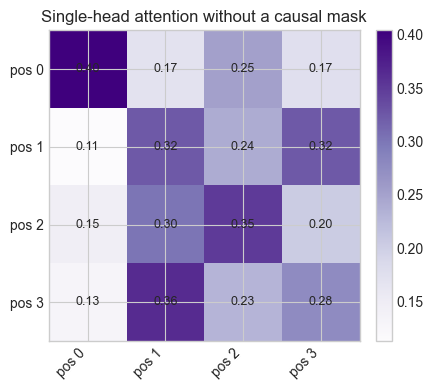

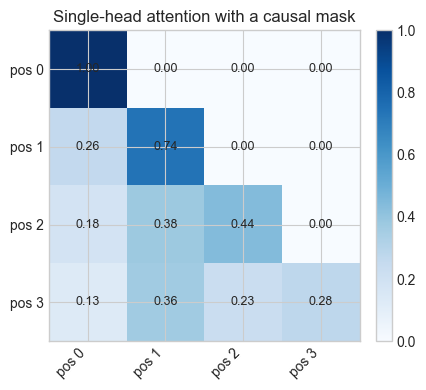

In [7]:
manual_states = combined_vectors.to(torch.float32)
labels = [f"pos {idx}" for idx in range(manual_states.shape[0])]

W_Q = torch.tensor([
    [0.7, 0.0, -0.2],
    [0.1, 0.5, 0.3],
    [-0.4, 0.2, 0.6],
    [0.3, -0.1, 0.2],
    [0.0, 0.4, -0.5],
    [0.2, 0.1, 0.4],
], dtype=torch.float32)
W_K = torch.tensor([
    [0.6, -0.2, 0.1],
    [0.2, 0.3, 0.0],
    [-0.1, 0.4, 0.5],
    [0.1, 0.2, -0.3],
    [0.5, -0.1, 0.2],
    [0.0, 0.3, 0.4],
], dtype=torch.float32)
W_V = torch.tensor([
    [0.2, 0.4, 0.1],
    [0.5, -0.2, 0.2],
    [0.0, 0.3, 0.6],
    [0.1, 0.1, -0.4],
    [0.4, 0.0, 0.2],
    [-0.2, 0.5, 0.3],
], dtype=torch.float32)

queries = manual_states @ W_Q
keys = manual_states @ W_K
values = manual_states @ W_V
raw_scores = queries @ keys.T
scaled_scores = raw_scores / math.sqrt(queries.shape[-1])
future_mask = torch.triu(torch.ones_like(scaled_scores), diagonal=1).bool()
masked_scores = scaled_scores.masked_fill(future_mask, float("-inf"))
unmasked_weights = F.softmax(scaled_scores, dim=-1)
masked_weights = F.softmax(masked_scores, dim=-1)
context_vectors = masked_weights @ values

print("Query vectors:")
print(rounded(queries))
print("\nScaled attention scores before masking:")
print(rounded(scaled_scores))
print("\nMasked attention weights:")
print(rounded(masked_weights))
print("\nEach row sums to:")
print(rounded(masked_weights.sum(dim=-1)))
print("\nContext vectors after attention:")
print(rounded(context_vectors))

plot_matrix(unmasked_weights, labels, labels, "Single-head attention without a causal mask", cmap="Purples")
plot_matrix(masked_weights, labels, labels, "Single-head attention with a causal mask", cmap="Blues")


### What I am looking at

The printed tensors show the full attention pipeline: projected queries, scaled scores, masked weights, and the final weighted sums of value vectors. The heatmaps make the masking effect visible.

### What changed here

Without a mask, each position could attend to the future. With the causal mask, every row is forced to place zero probability on tokens to its right.

### Why it matters

Autoregressive language models must predict the next token without peeking ahead. Causal masking is the rule that enforces that training and generation behavior match.


## From Explicit Math To Reusable PyTorch Modules

The by-hand attention calculation is good for intuition, but training a language model is easier once we package the same ideas into small modules.

The following definitions stay notebook-local and intentionally small so the computation remains inspectable.


In [8]:
def get_batch(token_ids, batch_size, block_size, device):
    max_start = len(token_ids) - block_size - 1
    starts = torch.randint(0, max_start + 1, (batch_size,))
    x = torch.stack([token_ids[start:start + block_size] for start in starts])
    y = torch.stack([token_ids[start + 1:start + block_size + 1] for start in starts])
    return x.to(device), y.to(device)


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, head_size, block_size):
        super().__init__()
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x, return_attention=False):
        _, time_steps, _ = x.shape
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(k.shape[-1])
        scores = scores.masked_fill(self.mask[:time_steps, :time_steps] == 0, float("-inf"))
        attention = F.softmax(scores, dim=-1)
        out = attention @ v
        if return_attention:
            return out, attention
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, block_size):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        head_size = d_model // num_heads
        self.heads = nn.ModuleList([
            CausalSelfAttention(d_model, head_size, block_size) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attention=False):
        if return_attention:
            head_outputs = []
            head_weights = []
            for head in self.heads:
                out, weights = head(x, return_attention=True)
                head_outputs.append(out)
                head_weights.append(weights)
            combined = torch.cat(head_outputs, dim=-1)
            projected = self.proj(combined)
            attention_stack = torch.stack(head_weights, dim=1)
            return projected, attention_stack

        combined = torch.cat([head(x) for head in self.heads], dim=-1)
        return self.proj(combined)


class TransformerMLP(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, d_model),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, block_size, mlp_hidden_dim):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, block_size)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = TransformerMLP(d_model, mlp_hidden_dim)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, block_size, mlp_hidden_dim):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, block_size, mlp_hidden_dim)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None, return_first_attention=False):
        _, time_steps = idx.shape
        if time_steps > self.block_size:
            raise ValueError(f"Sequence length {time_steps} exceeds block size {self.block_size}.")

        positions = torch.arange(time_steps, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)[None, :, :]

        first_attention = None
        for block_index, block in enumerate(self.blocks):
            if return_first_attention and block_index == 0:
                attn_input = block.ln1(x)
                attn_out, first_attention = block.attn(attn_input, return_attention=True)
                x = x + attn_out
                x = x + block.mlp(block.ln2(x))
            else:
                x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        if return_first_attention:
            return logits, loss, first_attention
        return logits, loss


@torch.no_grad()
def sample_from_model(model, prompt, encode, decode, max_new_tokens=60, temperature=0.8, top_k=8):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        next_token_logits = logits[:, -1, :]
        if temperature <= 0:
            next_idx = next_token_logits.argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, next_idx], dim=1)
            continue

        next_token_logits = next_token_logits / temperature
        if top_k is not None:
            values, _ = torch.topk(next_token_logits, min(top_k, next_token_logits.shape[-1]))
            cutoff = values[:, [-1]]
            next_token_logits = torch.where(
                next_token_logits < cutoff,
                torch.full_like(next_token_logits, float("-inf")),
                next_token_logits,
            )
        probs = F.softmax(next_token_logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_idx], dim=1)
    return decode(idx[0].tolist())


@torch.no_grad()
def trace_generation(model, prompt, encode, decode, max_new_tokens=10):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    trace = []
    for step in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        probs = F.softmax(logits[:, -1, :], dim=-1)
        top_probs, top_ids = torch.topk(probs, k=min(5, probs.shape[-1]))
        chosen = probs.argmax(dim=-1, keepdim=True)
        trace.append(
            {
                "step": step + 1,
                "context": decode(idx[0].tolist()),
                "chosen_token": decode([int(chosen.item())]),
                "top_choices": [
                    (decode([int(token_id)]), float(prob))
                    for token_id, prob in zip(top_ids[0], top_probs[0])
                ],
            }
        )
        idx = torch.cat([idx, chosen], dim=1)
    return trace, decode(idx[0].tolist())


@torch.no_grad()
def estimate_loss(model, token_ids, batch_size, block_size, eval_steps):
    model.eval()
    losses = []
    for _ in range(eval_steps):
        xb, yb = get_batch(token_ids, batch_size, block_size, device)
        _, loss = model(xb, yb)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def train_language_model(
    model,
    train_ids,
    val_ids,
    *,
    steps,
    batch_size,
    block_size,
    learning_rate,
    eval_interval,
    eval_steps,
    label,
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    history = {"steps": [], "train": [], "val": []}

    initial_train = estimate_loss(model, train_ids, batch_size, block_size, eval_steps)
    initial_val = estimate_loss(model, val_ids, batch_size, block_size, eval_steps)
    history["steps"].append(0)
    history["train"].append(initial_train)
    history["val"].append(initial_val)
    print(f"{label} | step   0 | train {initial_train:.3f} | val {initial_val:.3f}")

    model.train()
    for step in range(1, steps + 1):
        xb, yb = get_batch(train_ids, batch_size, block_size, device)
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step % eval_interval == 0 or step == steps:
            train_loss = estimate_loss(model, train_ids, batch_size, block_size, eval_steps)
            val_loss = estimate_loss(model, val_ids, batch_size, block_size, eval_steps)
            history["steps"].append(step)
            history["train"].append(train_loss)
            history["val"].append(val_loss)
            print(f"{label} | step {step:>3} | train {train_loss:.3f} | val {val_loss:.3f}")

    return history


print("Model, generation, and training helpers are ready.")


Model, generation, and training helpers are ready.


## Phase 5. Multi-Head Attention

A single head can only represent one attention pattern at a time. Multi-head attention gives the model several independent views of the same sequence and then mixes them back together.

Conceptually:

\[
\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W_O
\]


Input shape: (1, 4, 6)
Attention map stack shape: (1, 2, 4, 4)
Combined output shape: (1, 4, 6)
Combined output vectors:
tensor([[-0.5580, -0.0020, -0.1320,  0.4860,  0.3150,  0.1700],
        [-0.2130,  0.0830,  0.0800,  0.1660,  0.2230,  0.1590],
        [-0.2750,  0.1720,  0.1530,  0.1950,  0.2350,  0.0020],
        [-0.0470, -0.0010,  0.0150,  0.0820,  0.1810,  0.3390]])


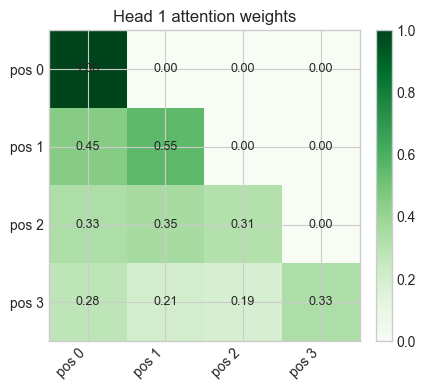

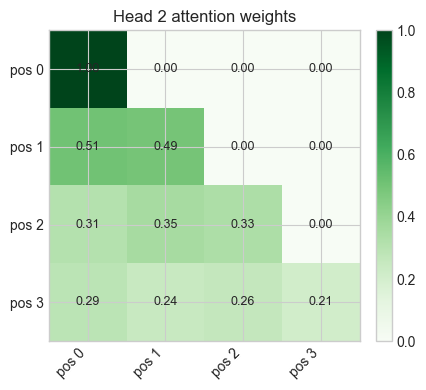

In [9]:
attention_demo = combined_vectors.unsqueeze(0)
multi_head = MultiHeadAttention(d_model=embedding_dim, num_heads=2, block_size=4)
multi_head_out, head_maps = multi_head(attention_demo, return_attention=True)

print("Input shape:", tuple(attention_demo.shape))
print("Attention map stack shape:", tuple(head_maps.shape))
print("Combined output shape:", tuple(multi_head_out.shape))
print("Combined output vectors:")
print(rounded(multi_head_out[0]))

for head_index in range(head_maps.shape[1]):
    plot_matrix(
        head_maps[0, head_index],
        labels,
        labels,
        f"Head {head_index + 1} attention weights",
        cmap="Greens",
    )


### What I am looking at

The same sequence has been processed by two different attention heads. Each head produced its own attention map, and their outputs were concatenated and projected back into the model dimension.

### What changed here

Instead of forcing one pattern of information flow, the model now learns several attention patterns in parallel.

### Why it matters

Different heads can specialize. One head might track nearby syntax, while another can learn longer-range dependencies.


## Phase 6. MLP, Residual Connections, And The Residual Stream

Attention mixes information across tokens, but each position also needs a position-wise transformation that can reshape its features.

That is the role of the MLP block. Residual connections then keep the original signal available:

\[
X_{\text{next}} = X + \text{Update}(X)
\]

The residual stream is the running representation that each block edits without erasing everything that came before.


In [10]:
residual_input = attention_demo.clone()
ln1 = nn.LayerNorm(embedding_dim)
ln2 = nn.LayerNorm(embedding_dim)
residual_attention = MultiHeadAttention(d_model=embedding_dim, num_heads=2, block_size=4)
residual_mlp = TransformerMLP(d_model=embedding_dim, hidden_dim=18)

attention_update = residual_attention(ln1(residual_input))
after_attention = residual_input + attention_update
mlp_update = residual_mlp(ln2(after_attention))
after_mlp = after_attention + mlp_update

print("First token before the block:")
print(rounded(residual_input[0, 0]))
print("\nFirst token after attention + residual:")
print(rounded(after_attention[0, 0]))
print("\nFirst token after MLP + residual:")
print(rounded(after_mlp[0, 0]))


First token before the block:
tensor([-0.1770,  0.7640, -1.7970, -0.1980, -0.0750, -0.5050])

First token after attention + residual:
tensor([-0.6860,  0.6910, -1.5130,  0.3290, -1.1850, -0.7980])

First token after MLP + residual:
tensor([-0.6230,  0.7280, -1.5540,  0.0480, -1.1130, -0.9250])


### What I am looking at

The same token representation is shown at three moments: before the block, after the attention update, and after the MLP update.

### What changed here

Each sublayer produced an update, and the residual connection added that update back to the running state instead of replacing it outright.

### Why it matters

Residual connections make deep transformer stacks trainable and interpretable. We can think of each block as editing a shared stream rather than starting from scratch.


## Phase 7. Transformer Block Composition

Now we can compose the pieces into a tiny autoregressive language model.

The full path is:

1. token ids
2. token embedding + positional embedding
3. repeated transformer blocks
4. final layer norm
5. logits over the vocabulary


In [11]:
demo_model = TinyTransformerLM(
    vocab_size=len(preview_chars),
    d_model=48,
    num_heads=4,
    num_layers=2,
    block_size=32,
    mlp_hidden_dim=96,
).to(device)

demo_text = toy_preview_text[:33]
demo_ids = torch.tensor(preview_encode(demo_text), dtype=torch.long)
xb = demo_ids[:-1].unsqueeze(0).to(device)
yb = demo_ids[1:].unsqueeze(0).to(device)
logits, loss = demo_model(xb, yb)

print("Demo text:", repr(demo_text))
print("Input batch shape:", tuple(xb.shape))
print("Logits shape:", tuple(logits.shape))
print("One-step cross-entropy loss:", round(loss.item(), 3))
print("Parameter count:", f"{count_parameters(demo_model):,}")


Demo text: 'The capital of France is Paris.\nT'
Input batch shape: (1, 32)
Logits shape: (1, 32, 44)
One-step cross-entropy loss: 4.015
Parameter count: 43,532


### What I am looking at

A full transformer language model has produced a logits tensor with shape `[batch, time, vocab]` and a cross-entropy loss against the next-token targets.

### What changed here

The earlier ideas have been composed into one differentiable mapping from context tokens to next-token predictions.

### Why it matters

This is the complete training interface for an autoregressive language model. Once we have logits and loss, gradient descent can start improving the model.


## Phase 8. Logits And Next-Token Prediction

The output of the language model is a vector of logits for every vocabulary item at every position.

A softmax turns the final-position logits into probabilities:

\[
P(\text{next token} \mid \text{context}) = \text{softmax}(\text{logits})
\]


In [12]:
last_position_probs = F.softmax(logits[0, -1], dim=-1).detach().cpu()
top_probs, top_ids = torch.topk(last_position_probs, k=5)
context_text = preview_decode(xb[0].detach().cpu().tolist())
target_token = preview_itos[int(yb[0, -1].detach().cpu().item())]

print("Context seen by the model:")
print(repr(context_text))
print("\nTrue next token:", repr(target_token))
print("\nTop 5 next-token probabilities:")
for rank, (token_id, probability) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
    print(f"{rank}. token={repr(preview_itos[token_id])} probability={probability:.3f}")


Context seen by the model:
'The capital of France is Paris.\n'

True next token: 'T'

Top 5 next-token probabilities:
1. token='z' probability=0.075
2. token='a' probability=0.071
3. token='3' probability=0.053
4. token='k' probability=0.051
5. token='E' probability=0.047


### What I am looking at

The final context position has been converted into a small ranked list of candidate next characters.

### What changed here

The transformer hidden state was projected back into vocabulary space, and softmax turned those scores into a normalized probability distribution.

### Why it matters

Language modeling is next-token prediction. Training pushes probability mass toward the true next token, and generation samples from that same distribution.


## Phase 9. Tiny Autoregressive Generation Demo

Generation simply repeats the same process: feed the current context in, take the final-position distribution, choose a next token, append it, and continue.

Before training, the model has no real language knowledge, so the output is mostly noise. That is useful to see because it gives us a baseline.


In [13]:
generation_trace, untrained_sample = trace_generation(
    demo_model,
    prompt="The capital of ",
    encode=preview_encode,
    decode=preview_decode,
    max_new_tokens=10,
)

for item in generation_trace:
    top_summary = ", ".join(
        f"{repr(token)}:{prob:.2f}" for token, prob in item["top_choices"]
    )
    print(f"Step {item['step']:>2} | context={repr(item['context'])}")
    print(f"         chose {repr(item['chosen_token'])} | top choices: {top_summary}")

print("\nFinal generated text:")
print(untrained_sample)


Step  1 | context='The capital of '
         chose 'q' | top choices: 'q':0.08, 'J':0.08, 'b':0.05, 'p':0.04, 'C':0.04
Step  2 | context='The capital of q'
         chose 'J' | top choices: 'J':0.07, 'z':0.05, '2':0.04, 'B':0.04, 'n':0.04
Step  3 | context='The capital of qJ'
         chose '2' | top choices: '2':0.06, 'n':0.06, 'i':0.05, 'T':0.05, 'r':0.04
Step  4 | context='The capital of qJ2'
         chose 'R' | top choices: 'R':0.07, 'A':0.06, 'T':0.04, 'a':0.04, 'D':0.04
Step  5 | context='The capital of qJ2R'
         chose 'q' | top choices: 'q':0.06, 'T':0.06, 'J':0.04, 'B':0.04, '2':0.04
Step  6 | context='The capital of qJ2Rq'
         chose '.' | top choices: '.':0.05, 'q':0.05, 'o':0.04, 'I':0.04, 'c':0.04
Step  7 | context='The capital of qJ2Rq.'
         chose '4' | top choices: '4':0.07, '.':0.06, '8':0.05, 'c':0.05, 'r':0.05
Step  8 | context='The capital of qJ2Rq.4'
         chose 'w' | top choices: 'w':0.07, 'D':0.05, 'F':0.04, 'd':0.04, 'I':0.04
Step  9 | context='T

### What I am looking at

Each step shows the current context, the token chosen at that step, and the highest-probability alternatives the untrained model considered.

### What changed here

The context window kept growing one token at a time. Every new prediction depended on the tokens generated so far.

### Why it matters

This is exactly how autoregressive generation works in larger models too. The only difference after training is that the probability distribution becomes meaningful.


## Phase 10. Stage A Training On Tiny Synthetic Text

Now we train on a tiny corpus we can understand almost line by line.

This stage is intentionally repetitive and structured. That makes the learning signal easy to interpret: if loss drops and generations improve, we can usually guess what pattern the model has captured.


In [14]:
stage_a_corpus = "\n".join(toy_sentences * 24)
stage_a_chars, stage_a_stoi, stage_a_itos, stage_a_encode, stage_a_decode = build_char_tokenizer(stage_a_corpus)
stage_a_ids = torch.tensor(stage_a_encode(stage_a_corpus), dtype=torch.long)
stage_a_split = int(0.9 * len(stage_a_ids))
stage_a_train_ids = stage_a_ids[:stage_a_split]
stage_a_val_ids = stage_a_ids[stage_a_split:]

print("Stage A corpus characters:", len(stage_a_ids))
print("Stage A vocabulary size:", len(stage_a_chars))
print("Training characters:", len(stage_a_train_ids))
print("Validation characters:", len(stage_a_val_ids))
print("\nCorpus preview:")
print(stage_a_corpus[:350])


Stage A corpus characters: 8663
Stage A vocabulary size: 44
Training characters: 7796
Validation characters: 867

Corpus preview:
The capital of France is Paris.
The capital of Italy is Rome.
The capital of Japan is Tokyo.
The capital of Brazil is Brasilia.
The capital of Egypt is Cairo.
The capital of India is New Delhi.
2 plus 2 equals 4.
3 plus 3 equals 6.
4 plus 4 equals 8.
The red bird sings at dawn.
The blue bird sings at dusk.
A small fox sees the moon.
A small fox see


### What I am looking at

This is the small synthetic dataset the model will see during the first training run. The patterns are intentionally repetitive and interpretable.

### What changed here

We turned the toy sentences into one continuous character stream, built a fresh vocabulary, and split the token ids into training and validation segments.

### Why it matters

A language model never sees isolated labels during training. It learns from contiguous sequences and is asked to predict the next token at every position.


Samples before training:

Prompt: 'The capital of France is '


The capital of France is nPRbqFo6k4umtBckisutCJcTbsz2pJwcTF8n6f. 

Prompt: '2 plus 2 equals '


2 plus 2 equals xTwNfeER4P3RJkqF4wDtpEwNqFoeks86aJgf2q6D

Prompt: 'A small fox '


A small fox IoCJE2qzJ.qFgno6a3pRkqwTaNaN32oghTdFob6f

Stage A | step   0 | train 3.878 | val 3.889


Stage A | step  20 | train 2.016 | val 2.014


...

Stage A | step  60 | train 1.164 | val 1.167


Stage A | step  80 | train 0.851 | val 0.858


Stage A | step 100 | train 0.586 | val 0.600


Stage A | step 120 | train 0.380 | val 0.376


Stage A | step 140 | train 0.253 | val 0.263


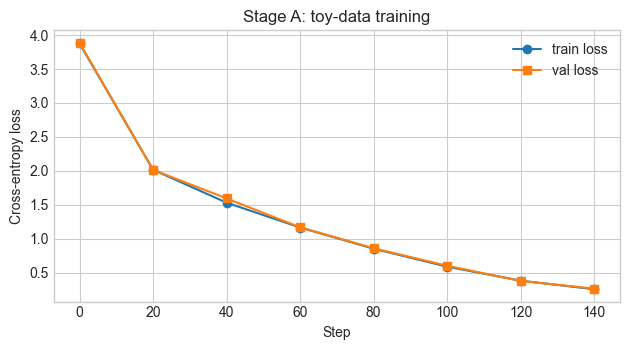

Samples after training:

Prompt: 'The capital of France is '


The capital of France is Pan.
The capital of Italy is

Prompt: '2 plus 2 equals '
2 plus 2 equals 4.
3 equals 4 plus 4 equals 

Prompt: 'A small fox '


A small fox sesun.
The capital of France



In [15]:
stage_a_model = TinyTransformerLM(
    vocab_size=len(stage_a_chars),
    d_model=64,
    num_heads=4,
    num_layers=2,
    block_size=64,
    mlp_hidden_dim=128,
).to(device)

stage_a_prompts = [
    "The capital of France is ",
    "2 plus 2 equals ",
    "A small fox ",
]

print("Samples before training:\n")
for prompt in stage_a_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_a_model, prompt, stage_a_encode, stage_a_decode, max_new_tokens=40))
    print()

stage_a_history = train_language_model(
    stage_a_model,
    stage_a_train_ids,
    stage_a_val_ids,
    steps=140,
    batch_size=24,
    block_size=64,
    learning_rate=3e-3,
    eval_interval=20,
    eval_steps=6,
    label="Stage A",
)
plot_loss_curves(stage_a_history, "Stage A: toy-data training")

print("Samples after training:\n")
for prompt in stage_a_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_a_model, prompt, stage_a_encode, stage_a_decode, max_new_tokens=28, temperature=0.4, top_k=4))
    print()


### What I am looking at

The output shows generations before training, the loss curve during training, and generations after training on the toy corpus.

### What changed here

Gradient descent adjusted the embedding table, attention weights, MLP weights, and output projection so the model became better at predicting the next character in the toy dataset.

### Why it matters

This is the first full end-to-end proof that the scratch-built transformer is learning something real. The loss should fall, and the generations should begin to reflect the toy patterns.


## Phase 11. Stage B Training On A Small Project Gutenberg Subset

Toy data is ideal for first principles, but it is useful to see the same machinery on real text.

We will use a small subset of *Alice's Adventures in Wonderland* from Project Gutenberg. The objective stays the same: next-character prediction.


In [16]:
gutenberg_url = "https://www.gutenberg.org/cache/epub/11/pg11.txt"
raw_gutenberg = requests.get(gutenberg_url, timeout=30).text


def strip_gutenberg_boilerplate(text):
    start_match = re.search(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text)
    end_match = re.search(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", text)
    start = start_match.end() if start_match else 0
    end = end_match.start() if end_match else len(text)
    return text[start:end].strip()


alice_text = strip_gutenberg_boilerplate(raw_gutenberg)
alice_text = alice_text.replace("\r", "")
alice_text = alice_text.translate(str.maketrans({
    "“": '"',
    "”": '"',
    "‘": "'",
    "’": "'",
    "—": "-",
    "–": "-",
    "…": "...",
}))
alice_text = "".join(ch for ch in alice_text if ch == "\n" or 32 <= ord(ch) < 127)
alice_text = re.sub(r"\n{3,}", "\n\n", alice_text)
stage_b_corpus = alice_text[:50000]
stage_b_chars, stage_b_stoi, stage_b_itos, stage_b_encode, stage_b_decode = build_char_tokenizer(stage_b_corpus)
stage_b_ids = torch.tensor(stage_b_encode(stage_b_corpus), dtype=torch.long)
stage_b_split = int(0.9 * len(stage_b_ids))
stage_b_train_ids = stage_b_ids[:stage_b_split]
stage_b_val_ids = stage_b_ids[stage_b_split:]

print("Downloaded characters:", len(raw_gutenberg))
print("Stage B subset characters:", len(stage_b_corpus))
print("Stage B vocabulary size:", len(stage_b_chars))
print("Training characters:", len(stage_b_train_ids))
print("Validation characters:", len(stage_b_val_ids))
print("\nSubset preview:\n")
print(stage_b_corpus[:700])


Downloaded characters: 167713
Stage B subset characters: 50000
Stage B vocabulary size: 71
Training characters: 45000
Validation characters: 5000

Subset preview:

[Illustration]

Alice's Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen's Croquet-Ground
 CHAPTER IX.    The Mock Turtle's Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice's Evidence

CHAPTER I.
Down the Rabbit-Hole

Alice was beginning to get very tired of sitting by her sister on the
bank, and of having


### What I am looking at

A real-text training corpus has been downloaded, cleaned, truncated to a Colab-friendly size, tokenized at character level, and split into training and validation segments.

### What changed here

We moved from highly structured toy sentences to natural text with richer punctuation, longer-range dependencies, and noisier local patterns.

### Why it matters

This stage bridges the gap between a didactic toy problem and a genuine language-modeling setting while keeping the runtime lightweight.


Samples before training:

Prompt: 'Alice was '


Alice was F!p?EdkbVh)Kw_BTCuaIOD0eP(arz-IjX]B_3frz-T[?XHdW.i!qz(aM,X))*[vedSFYfa3
]M[?sEym

Prompt: 'The Rabbit '


The Rabbit LO-OU-PD-t.EgQ"VrVqZ-0Zta;eOtwM"Il_trrZ;]KWTIl0"[Vh.)Q"y3uAHbieYZFQZNR(bD0 hs)[




Stage B | step   0 | train 4.457 | val 4.450


Stage B | step  20 | train 3.050 | val 3.091


Stage B | step  40 | train 2.795 | val 2.849


Stage B | step  60 | train 2.687 | val 2.734


Stage B | step  80 | train 2.603 | val 2.687


Stage B | step 100 | train 2.580 | val 2.612


Stage B | step 120 | train 2.568 | val 2.602


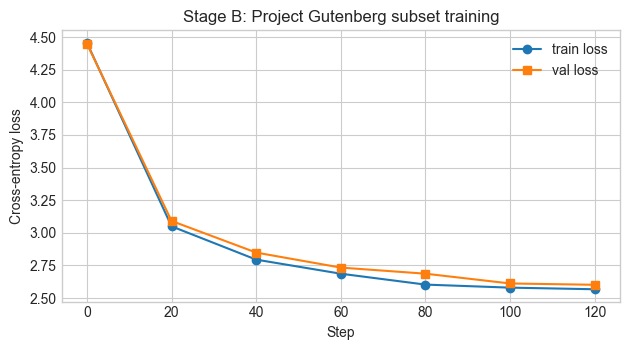

Samples after training:

Prompt: 'Alice was '


Alice was ton s t thowind the t t here wo the s the t het w s cashar t

Prompt: 'The Rabbit '


The Rabbit she we he won te he ouse we athang wathengoung t s t at on a



In [17]:
stage_b_model = TinyTransformerLM(
    vocab_size=len(stage_b_chars),
    d_model=64,
    num_heads=4,
    num_layers=2,
    block_size=96,
    mlp_hidden_dim=128,
).to(device)

stage_b_prompts = [
    "Alice was ",
    "The Rabbit ",
]

print("Samples before training:\n")
for prompt in stage_b_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_b_model, prompt, stage_b_encode, stage_b_decode, max_new_tokens=80, temperature=0.9, top_k=10))
    print()

stage_b_history = train_language_model(
    stage_b_model,
    stage_b_train_ids,
    stage_b_val_ids,
    steps=120,
    batch_size=16,
    block_size=96,
    learning_rate=2e-3,
    eval_interval=20,
    eval_steps=6,
    label="Stage B",
)
plot_loss_curves(stage_b_history, "Stage B: Project Gutenberg subset training")

print("Samples after training:\n")
for prompt in stage_b_prompts:
    print(f"Prompt: {repr(prompt)}")
    print(sample_from_model(stage_b_model, prompt, stage_b_encode, stage_b_decode, max_new_tokens=60, temperature=0.6, top_k=6))
    print()


### What I am looking at

This output compares real-text generations before and after a short training run on the Gutenberg subset and shows the corresponding training and validation losses.

### What changed here

The exact same scratch-built architecture that learned the toy corpus is now adapting to more varied text. The loss curve should still move downward, but the task is harder and the generations remain visibly small-model and short-run quality.

### Why it matters

This is the bridge from clean educational patterns to a more realistic corpus. It shows that the notebook implementation is not only conceptually correct but also operational on real text.


## Phase 12. GPT-2 Small Comparison

The scratch model and GPT-2 Small share the same core ideas:

- token embeddings
- positional information
- masked self-attention
- MLP sublayers
- residual connections
- autoregressive next-token prediction

What changes at GPT-2 scale is the tokenizer, the parameter count, the training data, and the amount of optimization work already baked into the pretrained weights.


In [18]:
comparison_text = "The capital of France is Paris."
try:
    gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2", local_files_only=True)
    gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2", local_files_only=True).to(device)
except Exception:
    with contextlib.redirect_stderr(io.StringIO()):
        gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
        gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
gpt2_model.eval()
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

gpt2_tokens = gpt2_tokenizer.tokenize(comparison_text)
gpt2_ids = gpt2_tokenizer.encode(comparison_text)

print("Word-level tokens:", word_tokens)
print("Character-level tokens:", list(comparison_text))
print("GPT-2 tokens:", gpt2_tokens)
print("GPT-2 token ids:", gpt2_ids)
print()
print("Scratch Stage B parameter count:", f"{count_parameters(stage_b_model):,}")
print("GPT-2 Small parameter count:", f"{count_parameters(gpt2_model):,}")
print("GPT-2 config summary:")
print({
    "layers": gpt2_model.config.n_layer,
    "heads": gpt2_model.config.n_head,
    "embedding_width": gpt2_model.config.n_embd,
    "context_window": gpt2_model.config.n_positions,
    "vocab_size": gpt2_model.config.vocab_size,
})


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Word-level tokens: ['The', 'capital', 'of', 'France', 'is', 'Paris', '.']
Character-level tokens: ['T', 'h', 'e', ' ', 'c', 'a', 'p', 'i', 't', 'a', 'l', ' ', 'o', 'f', ' ', 'F', 'r', 'a', 'n', 'c', 'e', ' ', 'i', 's', ' ', 'P', 'a', 'r', 'i', 's', '.']
GPT-2 tokens: ['The', 'Ġcapital', 'Ġof', 'ĠFrance', 'Ġis', 'ĠParis', '.']
GPT-2 token ids: [464, 3139, 286, 4881, 318, 6342, 13]

Scratch Stage B parameter count: 81,991
GPT-2 Small parameter count: 124,439,808
GPT-2 config summary:
{'layers': 12, 'heads': 12, 'embedding_width': 768, 'context_window': 1024, 'vocab_size': 50257}


### What I am looking at

The same sentence has been tokenized three ways, and the scratch model is being compared to GPT-2 Small in scale and configuration.

### What changed here

We moved from an educational character-level model to a pretrained byte-pair tokenizer and a much larger transformer with far more parameters and training history.

### Why it matters

This makes the continuity clear. GPT-2 is not a different species of model. It is the same core recipe, scaled up and pretrained much more extensively.


In [19]:
gpt2_prompt = "Alice was "
with torch.inference_mode():
    encoded_prompt = gpt2_tokenizer(gpt2_prompt, return_tensors="pt").to(device)
    generated_ids = gpt2_model.generate(
        **encoded_prompt,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.8,
        top_k=40,
        pad_token_id=gpt2_tokenizer.eos_token_id,
    )

gpt2_sample = gpt2_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
scratch_sample = sample_from_model(
    stage_b_model,
    prompt="Alice was ",
    encode=stage_b_encode,
    decode=stage_b_decode,
    max_new_tokens=70,
    temperature=0.6,
    top_k=6,
)

print("Scratch model sample:\n")
print(scratch_sample)
print("\nGPT-2 Small sample:\n")
print(gpt2_sample)


Scratch model sample:

Alice was t thit washe thise, the he ted thind s ing, woure s t t toulout ind w 

GPT-2 Small sample:

Alice was  in the middle of an argument with the young lady who was in the back alley of a restaurant and one guy was trying to kill him. She was crying, and that was the last thing she


### What I am looking at

A short prompt is being completed by both the notebook-trained scratch model and GPT-2 Small.

### What changed here

The pretrained model brings in large-scale prior knowledge from a much broader training distribution, so its continuation is typically more fluent and globally coherent.

### Why it matters

This comparison anchors the educational build in a real production-style transformer. It shows exactly what the scratch model captures and what scale and pretraining add on top.


## Phase 13. Final Synthesis

We built the transformer language-model pipeline from the inside out:

1. raw text became token ids
2. token ids became embeddings
3. positional embeddings injected order
4. attention mixed information across earlier tokens
5. multi-head attention let several patterns coexist
6. MLP blocks refined each position
7. residual connections preserved a running representation
8. the final linear layer produced logits over the vocabulary
9. softmax turned logits into next-token probabilities
10. autoregressive generation repeated that prediction loop one step at a time

Our notebook model is intentionally small and simplified:

- it uses a character-level tokenizer instead of GPT-2's subword tokenizer
- it trains on tiny corpora for a short time
- it keeps the architecture compact enough to inspect in a single notebook

But the conceptual core is the same. If you understand the mechanics in this notebook, you understand the backbone of modern autoregressive transformers.
